# Optic flow task


This notebook illustrates the optic flow task and how to use it with our pretrained fly visual system model and decoder.

**Select GPU runtime**

To run the notebook on a GPU select Menu -> Runtime -> Change runtime type -> GPU.

In [5]:
# @markdown **Check access to GPU**

try:
    import google.colab

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if True:
    import torch

    try:
        cuda_name = torch.cuda.get_device_name()
        print(f"Name of the assigned GPU / CUDA device: {cuda_name}")
    except RuntimeError:
        import warnings

        warnings.warn(
            "You have not selected Runtime Type: 'GPU' or Google could not assign you one. Please revisit the settings as described above or proceed on CPU (slow)."
        )

Name of the assigned GPU / CUDA device: NVIDIA GeForce RTX 2080


**Install Flyvis**

The notebook requires installing our package `flyvis`. You may need to restart your session after running the code block below with Menu -> Runtime -> Restart session. Then, imports from `flyvis` should succeed without issue.

In [6]:
# @markdown **Install Flyvis**
if IN_COLAB:
    !git clone https://github.com/TuragaLab/flyvis.git
    %cd /content/flyvis
    !pip install -e .[examples]

# The Sintel dataset

We use the Sintel dataset to train our models as described in the paper. More infos about the Sintel dataset can be found on the official Sintel website: http://sintel.is.tue.mpg.de/.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import os
from flyvis.analysis.animations.sintel import SintelSample
from flyvis.datasets.FT3D import MultiTaskFT3D
from flyvis.datasets.sintel import MultiTaskSintel
from pathlib import Path


The class `MultiTaskSintel` loads, preprocesses, renders, and augments the sintel data. It adheres to the pytorch dataset primitive. It provides the interface to the input data and the output data for the flyvis networks. Note: the fly-eye rendering we use here, we introduce in the notebook on creating custom stimuli already.

This is the full setting:

In [2]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    # Because the fly eye rendering is square
    # and sintel is wide, we can crop sintel
    # in width and render three sequences from one.
    # This allows us to statically augment our dataset
    # a bit already before we proceed with the random augmentations.
    # We end up with 3 * 23 sequences.
    vertical_splits=3,
    n_frames=19,
    center_crop_fraction=0.7,
    dt=1 / 50,
    augment=True,
    # From sequences with more than n_frames, we randomly sample the start frame.
    random_temporal_crop=True,
    all_frames=False,
    # We resample movie frames to the effective framerate given by 1/dt
    resampling=True,
    # We interpolate the flow arrows to 1/dt.
    interpolate=True,
    # We flip with equal probability (using one flip-axis).
    p_flip=0.5,
    flip_axes=[0, 1],
    # We rotate with equal probability (using five fold rotation symmetry of the hex-grid).
    p_rot=5 / 6,
    # We randomly adjust contrast and brightness.
    contrast_std=0.2,
    brightness_std=0.1,
    # We add random white noise pixelweise.
    gaussian_white_noise=0.08,
    gamma_std=None,
    _init_cache=True,
    unittest=False,
)
import os
from pathlib import Path

FT3D_ROOT      = Path(os.getenv("FT3D_ROOT", "/mnt/s/datasets/FlyingThings3D"))
augment = True
ft3d = MultiTaskFT3D(
        ft3d_path=FT3D_ROOT,
        tasks=["lum", "flow"],
        augment=augment,
        _init_cache=True,
    )

[2025-06-12 17:58:36] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet


hi
/mnt/s/datasets/FlyingThings3D
<generator object Path.rglob at 0x79cc12c5e020> /mnt/s/datasets/FlyingThings3D


Rendering FT3D: 100%|██████████| 2239/2239 [08:56<00:00,  4.17it/s]


RenderedFT3D_0000/ - Last modified: June 12, 2025 09:07:32
├── _meta.yaml
├── sequence_00000_A_0000_split_00/
│   ├── flow.h5
│   └── lum.h5
├── sequence_00000_A_0000_split_01/
│   ├── flow.h5
│   └── lum.h5
├── sequence_00000_A_0000_split_02/
│   ├── flow.h5
│   └── lum.h5
├── sequence_00001_A_0001_split_00/
│   ├── flow.h5
│   └── lum.h5
├── sequence_00001_A_0001_split_01/
│   ├── flow.h5
│   └── lum.h5
├── sequence_00001_A_0001_split_02/
│   ├── flow.h5
│   └── lum.h5
├── sequence_00002_A_0002_split_00/
│   ├── flow.h5
│   └── lum.h5
├── sequence_00002_A_0002_split_01/
│   ├── flow.h5
│   └── lum.h5
... length_limit, 25, reached,
displaying: 9 directories, 17 files, 2 levels.


In [3]:
# The `dataset.arg_df` tracks the sequence index, identity etc.
#dataset.arg_df
ft3d.arg_df

,index,original_index,name,original_n_frames
0,0,0,sequence_00000_A_0000_split_00,10
1,1,0,sequence_00000_A_0000_split_01,10
2,2,0,sequence_00000_A_0000_split_02,10
3,3,1,sequence_00001_A_0001_split_00,10
4,4,1,sequence_00001_A_0001_split_01,10
...,...,...,...,...
6712,6712,2237,sequence_02237_C_0748_split_01,10
6713,6713,2237,sequence_02237_C_0748_split_02,10
6714,6714,2238,sequence_02238_C_0749_split_00,10
6715,6715,2238,sequence_02238_C_0749_split_01,10


## Single sample

First, let's chunk this into smaller digestable pieces.

In [ ]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=1,
    dt=1 / 24,
    augment=False,
)

The first sample. For the target, the pixel-accurate motion vectors, the color indicates the direction of motion of the respective input pixel. The saturation indicates the magnitude of motion.

In [ ]:
# two back-to-back draws
lum1 = ft3d[2]["lum"]
lum2 = ft3d[2]["lum"]

print("identical?", torch.equal(lum1, lum2))   # almost always False


identical? True


Sintel has more groundtruth annotations. We support depth and flow because we know with some confidence that these are relevant for the fly.

In [ ]:
dataset = MultiTaskSintel(
    tasks=["depth"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=1,
    dt=1 / 24,
    augment=False,
)

[2025-06-10 10:08:53] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet
[2025-06-10 10:08:53] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet


In [ ]:
lum1 = dataset[0]["lum"]
depth1 = dataset[0]["depth"]

#animation = SintelSample(lum1[None], depth1[None])

#animation.animate_in_notebook()
dataset.arg_df

,index,original_index,name,original_n_frames
0,0,0,sequence_00_alley_1_split_00,50
1,1,1,sequence_01_alley_2_split_00,50
2,2,2,sequence_02_ambush_2_split_00,21
3,3,3,sequence_03_ambush_4_split_00,33
4,4,4,sequence_04_ambush_5_split_00,50
5,5,5,sequence_05_ambush_6_split_00,20
6,6,6,sequence_06_ambush_7_split_00,50
7,7,7,sequence_07_bamboo_1_split_00,50
8,8,8,sequence_08_bamboo_2_split_00,50
9,9,9,sequence_09_bandage_1_split_00,50


# Augmenting the dataset step-by-step

We apply rich augmentations to the dataset of naturalistic sequences because the dataset is otherwise relatively small. This might lead to overfitting to, e.g., predicting motion mostly into well-represented directons or of objects of specific contrasts etc. Using rich augmentations, we 'ask' the network to generalize better and invariantly compute motion regardless of direction, contrast, brightness, pixel noise, temporal appearance etc.

## Vertical splits

First, we split each sequence into three sequences vertically to leverage a wider extent of the video than if we would only render the center. We precompute these renderings.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import os
from flyvis.analysis.animations.sintel import SintelSample
from flyvis.datasets.FT3D import MultiTaskFlyingThings3D
from flyvis.datasets.sintel import MultiTaskSintel
from pathlib import Path
from flyvis.analysis.visualization.plots import quick_hex_scatter

In [ ]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=3,
    dt=1 / 24,
    augment=False,
)


[2025-06-12 16:32:49] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet


Sintel has 23 movie sequences originally.

In [ ]:
len(np.unique(dataset.arg_df.original_index))

23

Each original sequence is 436 pixel in height times 1024 pixel in width in cartesian coordinates.

With the vertical crops, we end up with 3 * 23 sequences. The `dataset.arg_df` tracks the sequence index, identity etc.

In [ ]:
dataset.arg_df

,index,original_index,name,original_n_frames
0,0,0,sequence_00_alley_1_split_00,50
1,1,0,sequence_00_alley_1_split_01,50
2,2,0,sequence_00_alley_1_split_02,50
3,3,1,sequence_01_alley_2_split_00,50
4,4,1,sequence_01_alley_2_split_01,50
...,...,...,...,...
64,64,21,sequence_21_temple_2_split_01,50
65,65,21,sequence_21_temple_2_split_02,50
66,66,22,sequence_22_temple_3_split_00,50
67,67,22,sequence_22_temple_3_split_01,50


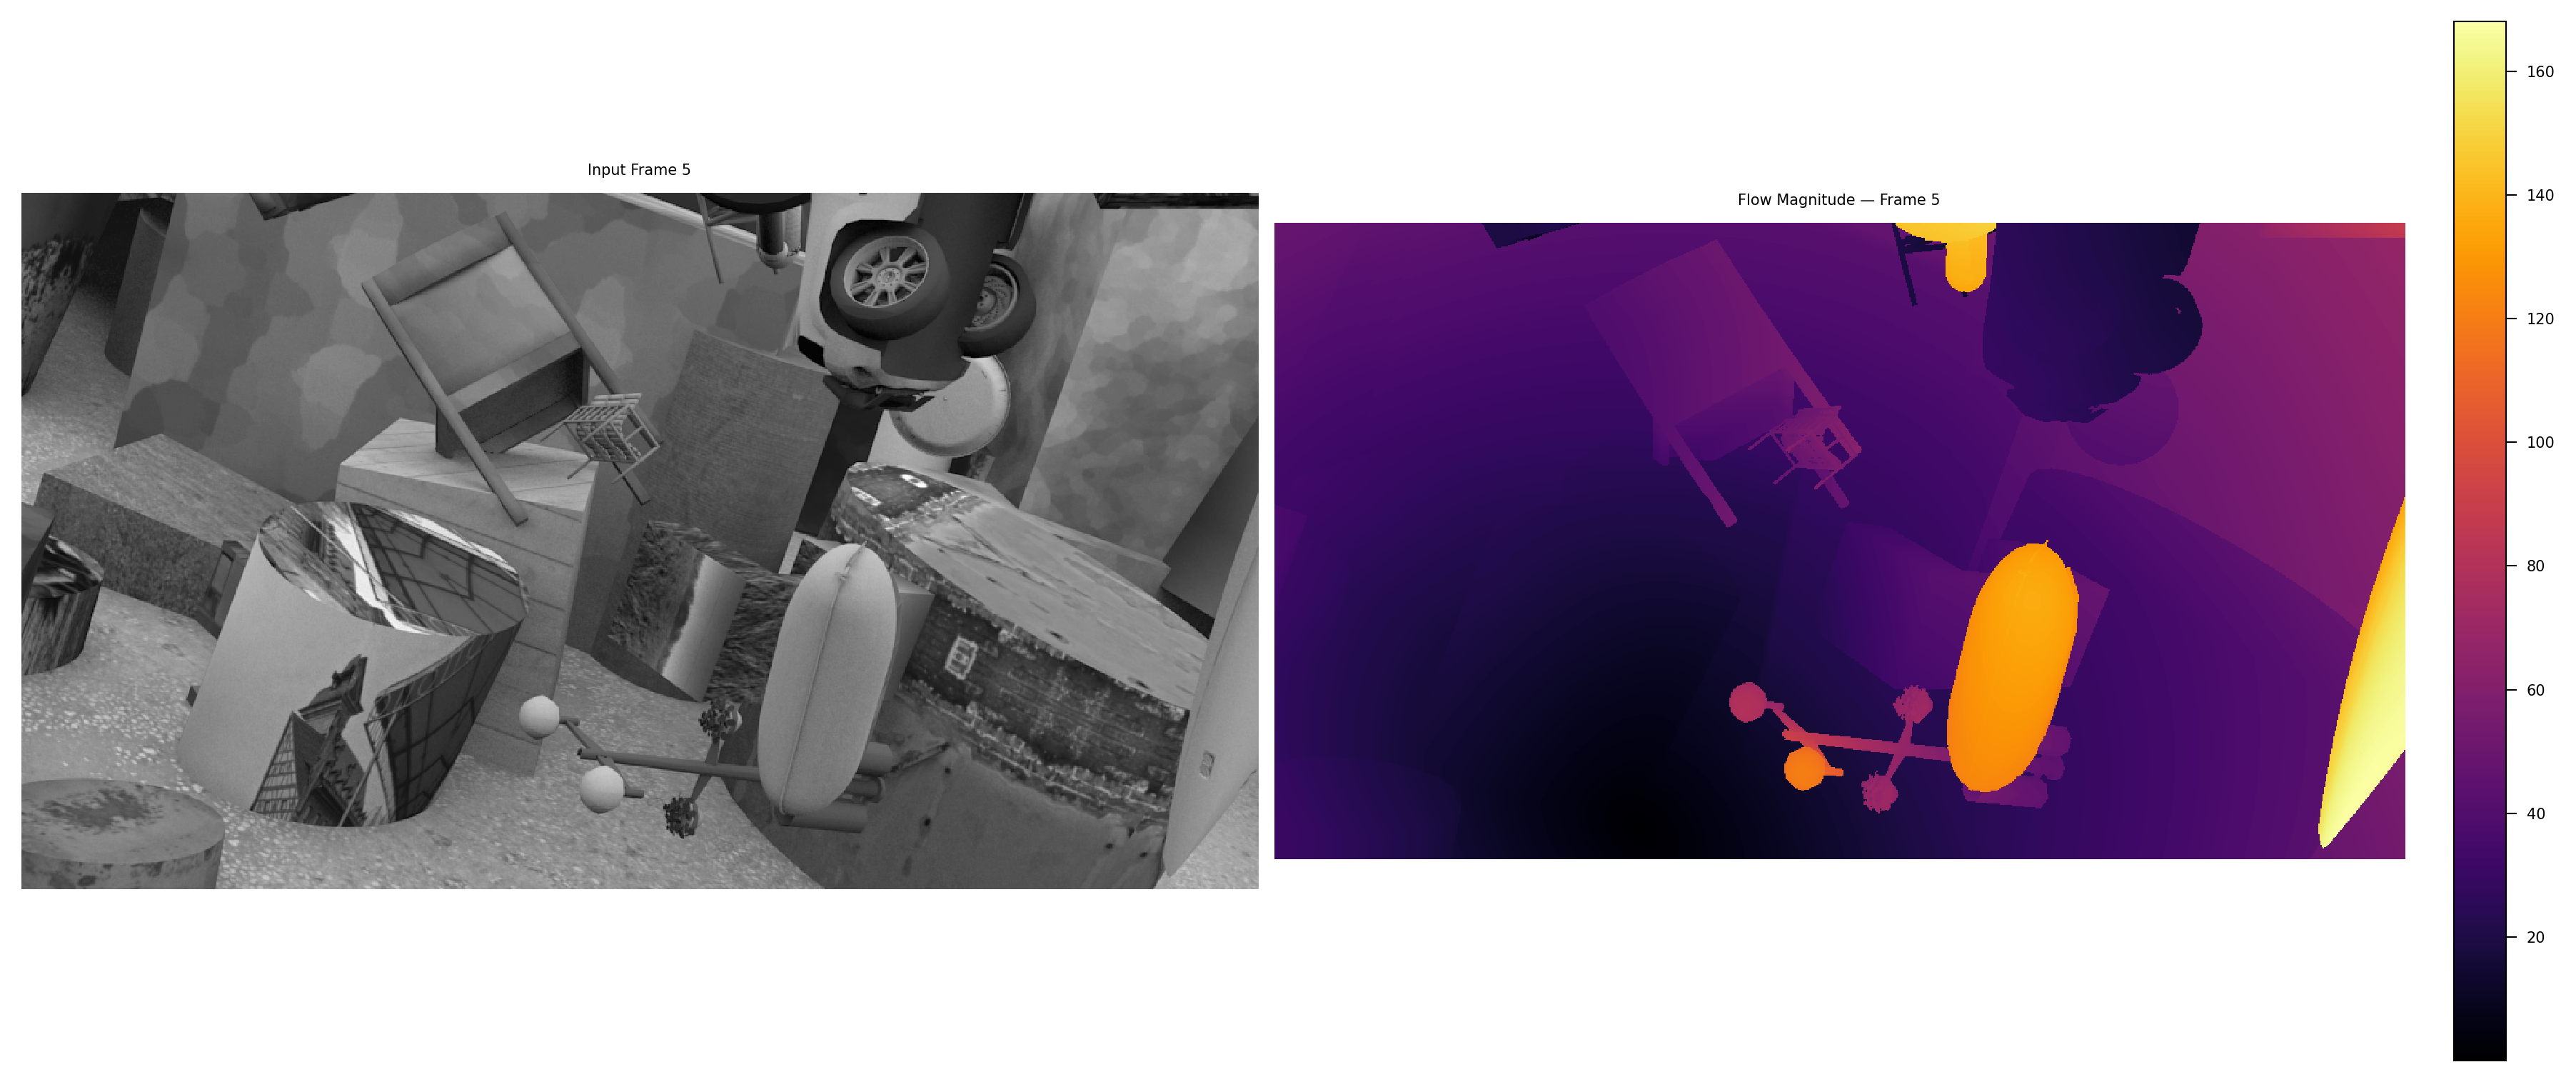

In [ ]:
sequence_default = ft3d.cartesian_sequence(5, vertical_splits=1, center_crop_fraction=1.0)
flow_default = ft3d.cartesian_flow(5, vertical_splits=1, center_crop_fraction=1.0)

t = 5                                               # frame index
frame = sequence_default[0, t]                      # H × W × 3
flow  = flow_default[0, t]                          # H × W × 2  ← already (…,2)

flow_mag = np.linalg.norm(flow, axis=2)             # H × W

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].imshow(frame, cmap='gray')
axs[0].set_title(f"Input Frame {t}")
axs[0].axis('off')

im = axs[1].imshow(flow_mag, cmap='inferno')
axs[1].set_title(f"Flow Magnitude — Frame {t}")
axs[1].axis('off')
fig.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [ ]:
flow_custom = normalized_ft3d.cartesian_flow(0, vertical_splits=1, center_crop_fraction=1.0)
frame =flow_custom[0, 0]            # (540, 960, 2)

flow_mag = np.linalg.norm(frame, axis=2)   # (540, 960)

plt.figure(figsize=(8, 6))
plt.imshow(flow_mag, cmap='inferno', origin='upper')
plt.colorbar(label='Flow magnitude')
plt.axis('off')
plt.tight_layout()
plt.show()


NameError: name 'normalized_ft3d' is not defined

In [ ]:
fig, axes = plt.subplots(1, 3)
_ = quick_hex_scatter(dataset[0]['lum'][0].flatten(), fig=fig, ax=axes[0], cbar=False)
_ = quick_hex_scatter(dataset[1]['lum'][0].flatten(), fig=fig, ax=axes[1], cbar=False)
_ = quick_hex_scatter(dataset[2]['lum'][0].flatten(), fig=fig, ax=axes[2], cbar=False)

## Random temporal crops

We train on 19 frames ~ 792ms movie. Most sequences have 49 frames. To use the whole temporal content, we stochastically sample start and end frame ~ ((1, 19), (2, 20), ..., (31, 49)).

In [ ]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=3,
    n_frames=19,
    dt=1 / 24,
    augment=True,
    random_temporal_crop=True,
    all_frames=False,
    resampling=False,
    interpolate=False,
    p_flip=0,
    p_rot=0,
    contrast_std=None,
    brightness_std=None,
    gaussian_white_noise=None,
)

In [ ]:
# These two samples from the same original sequence should have stochastically different start and end frames.
lum1 = dataset[0]['lum']
lum2 = dataset[0]['lum']

In [ ]:
animation = SintelSample(lum1[None], lum2[None], title2="input")
animation.animate_in_notebook()

## Flips and rotations

Next, we flip stochastically across 2 axes and or rotate a random number of times around the center. We implement this to be fast to do so at runtime.

In [25]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=3,
    n_frames=19,
    dt=1 / 24,
    augment=True,
    random_temporal_crop=False,
    all_frames=False,
    resampling=False,
    interpolate=False,
    p_flip=1 / 2,
    p_rot=5 / 6,
    contrast_std=None,
    brightness_std=None,
    gaussian_white_noise=None,
)

[2025-06-16 15:18:33] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet


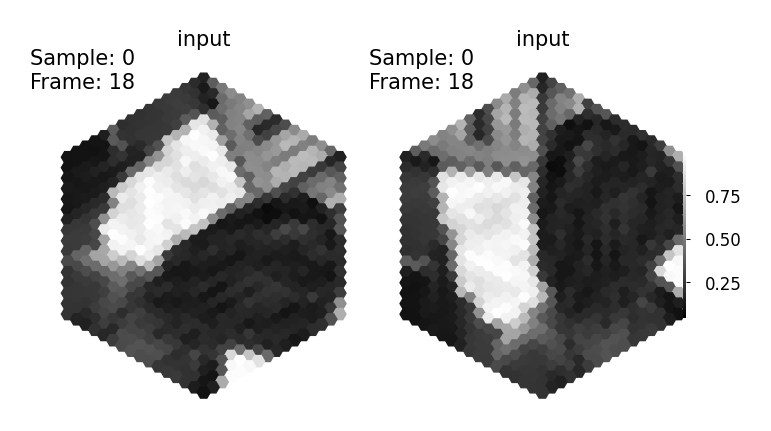

In [ ]:
# These two samples from the same original sequence should have stochastically different orientation.
lum1 = dataset[0]['lum']
lum2 = dataset[0]['lum']
animation = SintelSample(lum1[None], lum2[None], title2="input")
animation.animate_in_notebook()

Flow vectors need to be flipped and rotated accordingly.

In [ ]:
# These two samples from the same original sequence should have stochastically different orientation.
data = dataset[0]
lum1 = data['lum']
flow1 = data['flow']
animation = SintelSample(lum1[None], flow1[None])
animation.animate_in_notebook()

## Further augmentations

Besides that, we also augment the input with random contrasts and brightnesses and random gaussian pixel noise, while the motion stays the same. This pretends that the same motion takes place under different illumination conditions and signal to noise ratios.  

In [ ]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=3,
    n_frames=19,
    dt=1 / 24,
    augment=True,
    random_temporal_crop=False,
    all_frames=False,
    resampling=False,
    interpolate=False,
    p_flip=0,
    p_rot=0,
    contrast_std=0.2,
    brightness_std=0.1,
    gaussian_white_noise=0.08,
)

In [ ]:
# These two samples from the same original sequence have
# stochastically different contrast, brightness and pixel-wise noise.
lum1 = dataset[0]['lum']
lum2 = dataset[0]['lum']

In [ ]:
animation = SintelSample(lum1[None], lum2[None], title2="input")
animation.animate_in_notebook()

# Framerate of the dataset and integration time step

The Sintel dataset is originally rendered at 24 frames per second, i.e., one frame every 42ms. The fruit fly neurons are able to respond to temporal differences as fast as 5-20ms. Therefore, we resample every frame multiple times to pretend that the movie was originally sampled at such a faster framerate. For the motion fields, we interpolate flow vectors in time instead of resampling them, which hopefully gives a better learning signal to the network. We have to trade-off speed of the numerical integration and memory consumption during optimization with the simulation accuracy by choosing time steps between 5-20ms. We chose to train networks at the upper bount of 20ms and evaluate them more accurately at 5-10ms.

In [ ]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=3,
    n_frames=19,
    dt=1 / 50,
    augment=False,
    resampling=True,
    interpolate=True,
)


In [ ]:
# Now, every input frame appears twice and target frames are interpolated.
data = dataset[0]
lum1 = data['lum']
flow1 = data['flow']

In [ ]:
animation = SintelSample(lum1[None], flow1[None])
animation.animate_in_notebook()

# Computing responses to the Sintel data

Before we get to training a network, we look at a few responses to these type of sequences of individual neurons.

In [ ]:
from flyvis.datasets.sintel import MultiTaskSintel
from flyvis.network import Network
from flyvis.utils.activity_utils import LayerActivity

In [ ]:
# new network instance
network = Network()

# Alternative: uncomment to use a pretrained network
# network_view = NetworkView(results_dir / "flow/0000/000")
# network = network_view.init_network(network)

In [ ]:
layer_activity = LayerActivity(None, network.connectome, keepref=True)

In [ ]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=1,
    n_frames=19,
    dt=1 / 50,
    augment=False,
    resampling=True,
    interpolate=True,
)
dataset = dataset1

In [ ]:
stationary_state = network.fade_in_state(1.0, dataset.dt, dataset[0]["rgb"][[0]])
responses = network.simulate(
    dataset[0]["rgb"][None], dataset.dt, initial_state=stationary_state
).cpu()

In [ ]:
plt.figure(figsize=[3, 2])
layer_activity.update(responses)
r = layer_activity.central.T4c.squeeze().numpy()
time = np.arange(0, r.shape[0], 1) * dataset.dt
plt.plot(time, r)
plt.xlabel("time in s")
plt.ylabel("voltage (a.u.)")
plt.title("response of central T4c cell")

# Decoding the task from neural activity

We need to predict the pixel-accurate flow field that Sintel gives us. For that we decode the voltages of a bunch of cell types. The decoder and the network are trained end-to-end. Here an example of a forward pass through the whole pipeline in code.

In [ ]:
network = Network()

In [ ]:
decoder = DecoderGAVP(network.connectome, shape=[8, 2], kernel_size=5)

In [ ]:
dataset = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=1,
    all_frames=True,
    dt=1 / 50,
    augment=False,
    resampling=True,
    interpolate=True,
)

In [ ]:
data = dataset[0]
lum = data["lum"]
flow = data["flow"]

stationary_state = network.fade_in_state(1.0, dataset.dt, lum[[0]])
responses = network.simulate(lum[None], dataset.dt, initial_state=stationary_state)

In [ ]:
y_pred = decoder(responses)

In [ ]:
data = dataset[0]
lum = data["lum"]
flow = data["flow"]

stationary_state = network.fade_in_state(1.0, dataset.dt, lum[[0]])
responses = network.simulate(lum[None], dataset.dt, initial_state=stationary_state)
animation = SintelSample(lum[None], flow[None], prediction=y_pred.detach().cpu())
animation.animate_in_notebook(frames=np.arange(lum.shape[0])[::10])

We predict motion with an untrained decoder from an untrained network with randomly initialized parameters. 
We do not expect this to work.

In [ ]:
data = dataset1[0]
lum = data["rgb"]
flow = data["flow"]

stationary_state = network.fade_in_state(1.0, dataset.dt, lum[[0]])
responses = network.simulate(lum[None], dataset.dt, initial_state=stationary_state)
animation = SintelSample(lum[None], flow[None], prediction=y_pred.detach().cpu())
#animation.animate_in_notebook(frames=np.arange(lum.shape[0])[::10])
#animation = SintelSample(lum[None], flow[None])
animation.animate_in_notebook()

In [ ]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from flyvis.datasets.FT3D import MultiTaskFlyingThings3D
from flyvis.datasets.sintel import MultiTaskSintel

# ───── Load datasets ─────
sintel = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=1,
    n_frames=19,
    dt=1 / 50,
    augment=False,
    resampling=True,
    interpolate=True,
)

FT3D_ROOT = Path(os.getenv("FT3D_ROOT", "/mnt/s/datasets/FlyingThings3D"))
ft3d = MultiTaskFlyingThings3D(
    ft3d_path=FT3D_ROOT,
    tasks=["lum", "flow"],
    augment=True,
    _init_cache=True,
)

# ───── Helper to extract all magnitudes ─────
def get_all_magnitudes(dataset, key="flow"):
    all_mags = []
    for i in range(len(dataset)):
        flow = dataset[i][key].cpu().numpy()
        mags = np.linalg.norm(flow.reshape(-1, 2), axis=-1)
        all_mags.append(mags)
    return np.concatenate(all_mags)

# ───── Compute magnitude stats ─────
mags_ft3d = get_all_magnitudes(ft3d, key="flow")
mags_sintel = get_all_magnitudes(sintel, key="flow")

mag_95 = np.percentile(mags_ft3d, 95)
print(f"95th percentile of FT3D flow magnitude: {mag_95:.4f}")

# ───── Apply normalization to sample ─────
flow_sample = ft3d[15]["flow"].cpu().numpy()
flow_normalized = flow_sample / mag_95 *100

# ───── Plot comparison ─────
plt.hist(np.linalg.norm(flow_normalized.reshape(-1, 2), axis=1), bins=100, alpha=0.5, label="FT3D (95%-normalized)")
plt.hist(mags_sintel, bins=100, alpha=0.5, label="Sintel")
plt.yscale("log")
plt.legend()
plt.title("Flow Magnitude Distributions (FT3D normalized vs Sintel)")
plt.xlabel("Flow Magnitude")
plt.ylabel("Frequency (log scale)")
plt.grid(True)
plt.show()


[2025-06-12 15:23:53] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet


KeyboardInterrupt: 

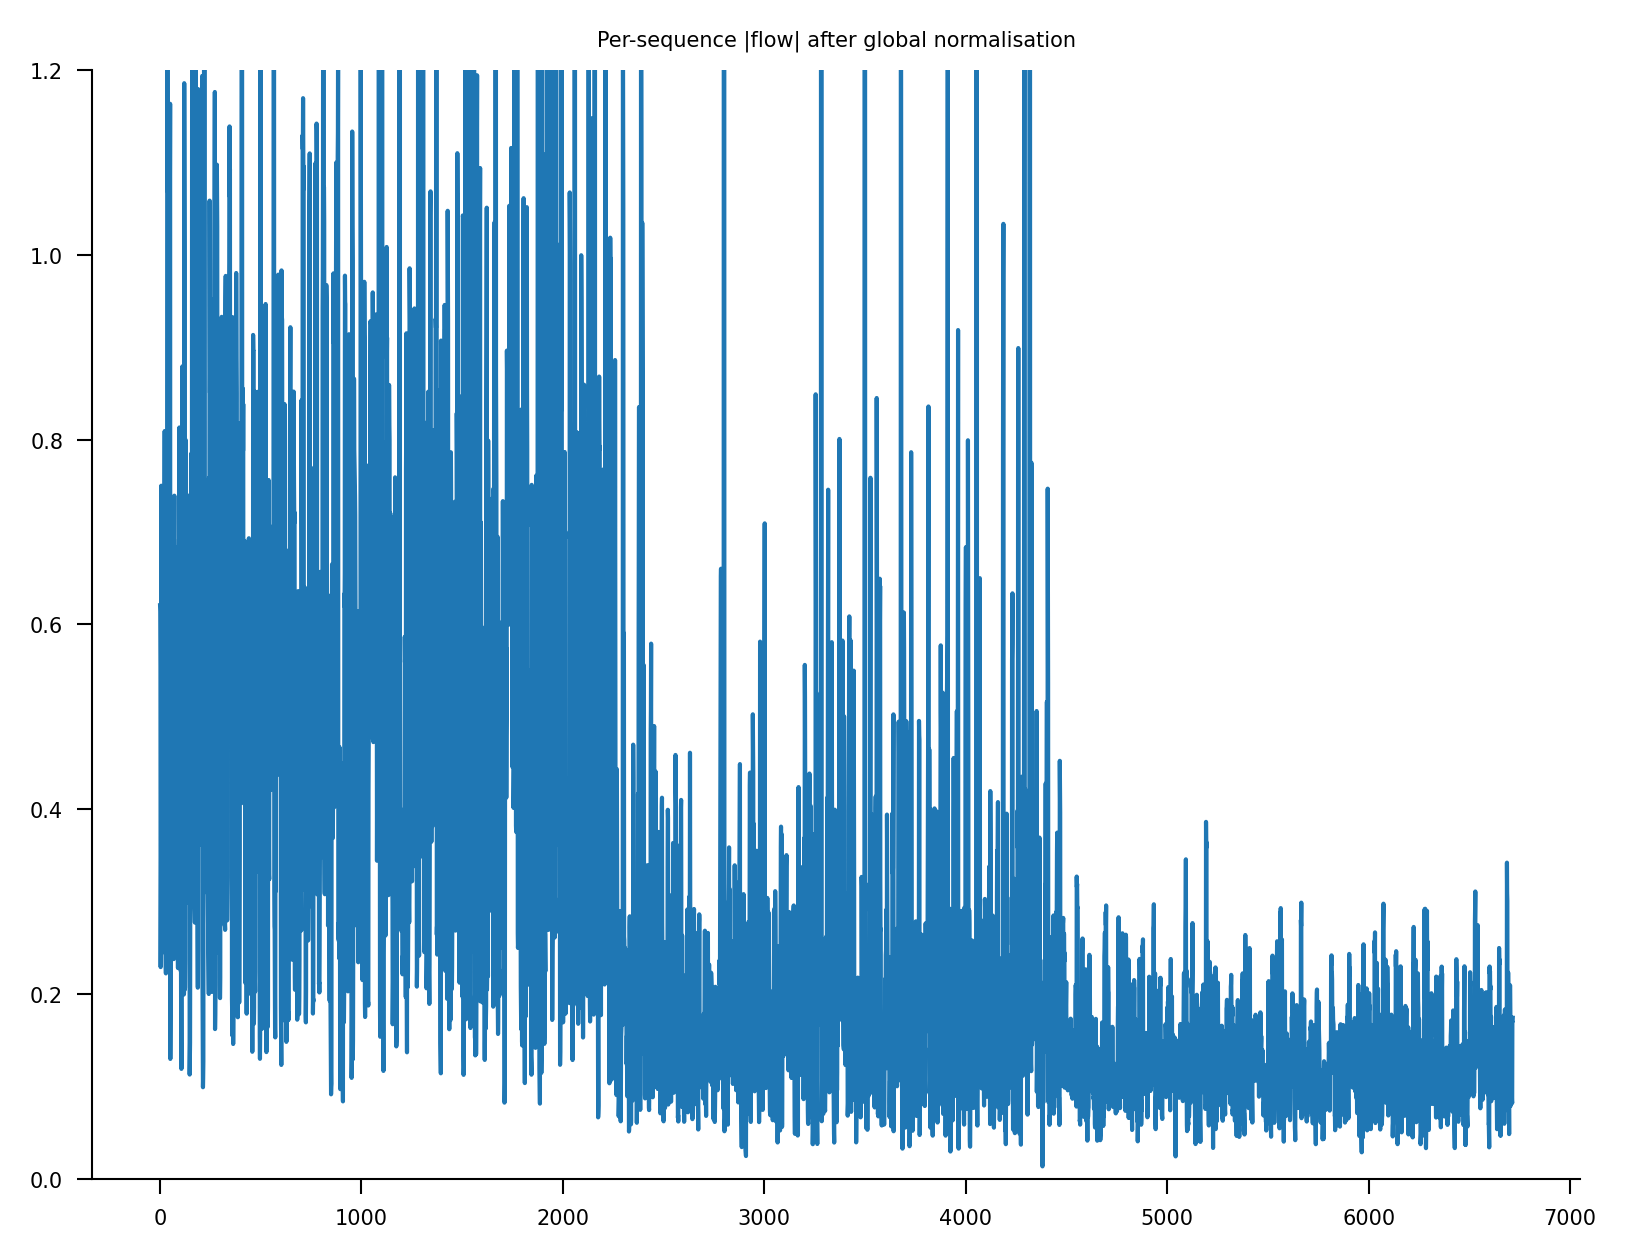

NameError: name 'stats' is not defined

<Figure size 2400x900 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from flyvis.datasets.FT3D import MultiTaskFlyingThings3D

train_loader = DataLoader(
    normalized_ft3d,
    batch_size=16,
    shuffle=True,
    num_workers=4,
)

stats_norm = []
for i in range(len(normalized_ft3d)):
    flow = normalized_ft3d[i]["flow"]
    mags = torch.linalg.vector_norm(flow, dim=1)
    stats_norm.append(mags.mean().item())

plt.plot(stats_norm); plt.ylim(0, 1.2)
plt.title("Per-sequence |flow| after global normalisation")
plt.show()



In [ ]:
# 1.  See which original folder each plotted point refers to
for i in [1895, 1900, 1905]:
    print(i, ft3d.arg_df.name[i])          # needs arg_df from init_cache

# 2.  Compare average magnitude by group letter
groups = {}
for name in ft3d.arg_df.name:
    grp = name.split('_')[2]              # A / B / C
    groups.setdefault(grp, []).append(name)
print({g: len(v) for g, v in groups.items()})

# 3.  Mean |flow| for first 100 and last 100 sequences
def seq_mean(idx):
    mag = torch.linalg.vector_norm(ft3d[idx]['flow'], dim=1)
    return mag.mean().item()
print(np.mean([seq_mean(i) for i in range(100)]))
print(np.mean([seq_mean(i) for i in range(len(ft3d)-100, len(ft3d))]))


1895 sequence_00701_A_0705_split_02
1900 sequence_00704_A_0708_split_01
1905 sequence_00706_A_0710_split_00
{'A': 2019, 'C': 2241}
61.985610752105714
17.723037400245666


# Training network and decoder on a single batch

We now train the network on a single batch to validate that the pipeline works. We do not expect these networks to generalize their function.

In [1]:
import os
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.optim import Adam
from torch.utils.data import DataLoader, Subset
from tqdm.notebook import tqdm

from flyvis.analysis.animations.sintel import SintelSample
from flyvis.connectome import *
from flyvis.datasets.FT3D import MultiTaskFT3D
from flyvis.datasets.sintel import MultiTaskSintel
from flyvis.network import Network
from flyvis.network.network import Network
from flyvis.task.decoder import DecoderGAVP
from flyvis.task.objectives import epe

import math


sintel = MultiTaskSintel(
    tasks=["flow"],
    boxfilter=dict(extent=15, kernel_size=13),
    vertical_splits=1,
    n_frames=19,
    dt=1 / 50,
    augment=False,
    resampling=True,
    interpolate=True,
)

FT3D_ROOT      = Path(os.getenv("FT3D_ROOT", "/mnt/s/datasets/FlyingThings3D"))
ft3d = MultiTaskFT3D(
        ft3d_path=FT3D_ROOT,
        tasks=["lum", "flow"],
        augment=True,
        interpolate=True,  resampling=True,
        n_frames=9,
        _init_cache=True,
    )

n_total = len(ft3d)
start   = math.floor(2 * n_total / 3)      # first element in the last third
indices = list(range(start, n_total))      # e.g. [1333, 1334, …, 1999]

# ---- 2. wrap the original dataset ----
ft3d = Subset(ft3d, indices)
# 1⃣  Grab defaults and make an editable copy
base_cfg = deepcopy(Network().config)

base_cfg.edge_config.syn_strength.groupby =[
                "source_type", "target_type",
                "source_index", "target_index",
            ]
net_custom = Network(
    node_config=base_cfg.node_config,
    edge_config=base_cfg.edge_config,    # keep the rest unchanged
    connectome=base_cfg.connectome,
    dynamics=base_cfg.dynamics,
    stimulus_config=base_cfg.stimulus_config,
)

[2025-06-16 17:01:41] sintel_utils:331 Found Sintel at /home/z/flyvis/data/SintelDataSet
[2025-06-16 17:04:13] network:222 Initialized network with NumberOfParams(free=734, fixed=2959) parameters.
[2025-06-16 17:04:17] network:222 Initialized network with NumberOfParams(free=1513361, fixed=2959) parameters.


In [2]:
#net_default = Network()

In [3]:
# These two samples from the same original sequence should have stochastically different orientation.
#lum1 = ft3d[2]['lum']
#lum2 = ft3d[2]['lum']
#animation = SintelSample(lum1[None], lum2[None], title2="input")
#animation.animate_in_notebook()

In [6]:
def log_scale_flow(flow, eps=1e-12):
    """
    flow : tensor (..., 2)   (H×W×2, 2×H×W, whatever)
    returns flow / log(1 + ||flow||)
    """
    mag   = torch.linalg.norm(flow, dim=-1, keepdim=True)       # (...,1)
    scale = torch.log1p(mag).clamp_min_(eps)                    # avoid /0
    return flow / scale                                         # broadcast
def inverse_transform(v_hat, mag95, tol=1e-8, max_iter=8):
    # undo global scale
    v_hat = v_hat * mag95

    # solve f(r)=0 where f(r)=r/log(1+r) - r_hat
    r_hat = torch.linalg.norm(v_hat, dim=-1, keepdim=True)
    r = r_hat.clone()                                  # init

    for _ in range(max_iter):
        f   = r / torch.log1p(r) - r_hat
        fp  = (torch.log1p(r) - r/(1+r)) / torch.log1p(r)**2  # df/dr
        step = f / fp
        r   = r - step
        if (step.abs() < tol).all():                   # early stop
            break

    return v_hat * (r / r_hat.clamp_min(1e-12))

# ---------- gather global 95-th-percentile --------------------
def get_mags(ds, key="flow"):
    mags = []
    for i in range(len(ds)):
        f = ds[i][key]                    # shape 2×H×W  or H×W×2
        if f.ndim == 3 and f.shape[0] == 2:
            f = f.permute(1, 2, 0)        # → H×W×2   (no data copy)
        v = f.reshape(-1, 2)              # safe even if non-contiguous
        mags.append(torch.linalg.norm(v, dim=-1))
    return torch.cat(mags).cpu()




# ---------- dataset wrapper ----------------------------------
class FT3DLogNorm(torch.utils.data.Dataset):
    """
    1. Per-vector divide by log(1+||v||)
    2. Global divide by mag_95   (optional but handy for batching)
    """
    def __init__(self, base_ds, mag95=None, eps=1e-12):
        self.base  = base_ds
        self.mag95 = mag95
        self.eps   = eps

    def __len__(self): return len(self.base)

    def __getitem__(self, idx):
        sample   = self.base[idx].copy()
        flow     = sample["flow"]
        flow     = log_scale_flow(flow, self.eps)          # step 1
        if self.mag95 is not None:
            flow = flow / self.mag95                       # step 2
        sample["flow"] = flow
        return sample

# ---------- create the normalised dataset --------------------
mags_ft3d = get_mags(ft3d)               # before any scaling
mag_95 = np.percentile(mags_ft3d, 95)  # scalar   # ~20 k vectors instead of billions
ft3d_norm = FT3DLogNorm(ft3d, mag_95)

In [7]:
torch.cuda.empty_cache()         # clears *cached* but not live memory
torch.cuda.ipc_collect()         # optional: clears inter-process handles
import gc

gc.collect()
a = torch.zeros(300000000, dtype=torch.int8)
a = a.cuda()
del a
torch.cuda.empty_cache()


In [10]:
epochs = 100
t_pre = 0.5
dt = 1 / 50
batch_size = 16
train_loader = DataLoader(ft3d_norm, batch_size=batch_size,drop_last=True)
lr= 1e-3



In [11]:
loss_fn = epe
decoder_custom  = DecoderGAVP(net_custom.connectome, shape=[32,16,8,2], kernel_size=9) ##higher kernal size
initial_state_custom  = net_custom.steady_state(t_pre, dt, batch_size).detach()
opt_custom = Adam(
    (*net_custom.parameters(), *decoder_custom.parameters()), lr=lr, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    opt_custom, T_max=epochs, eta_min=1e-5
)


[2025-06-16 17:10:17] decoder:282 Initialized decoder with NumberOfParams(free=142083, fixed=0) parameters.
[2025-06-16 17:10:17] decoder:283 DecoderGAVP(
  (base): Sequential(
    (0): Conv2dHexSpace(34, 32, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Softplus(beta=1.0, threshold=20.0)
    (3): Dropout(p=0.5, inplace=False)
    (4): Conv2dHexSpace(32, 16, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
    (5): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Softplus(beta=1.0, threshold=20.0)
    (7): Dropout(p=0.5, inplace=False)
    (8): Conv2dHexSpace(16, 8, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
    (9): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): Softplus(beta=1.0, threshold=20.0)
    (11): Dropout(p=0.5, inplace=False)
  )
  (decoder): Sequential(
    (0): Conv2dHexSpace(8, 3,

In [12]:
def grad_stats(model: torch.nn.Module) -> float:
    g = [p.grad.abs().mean() for p in model.parameters() if p.grad is not None]
    return torch.stack(g).mean().item() if g else 0.



# ── set-up (same as before) ────────────────────────────────────────────
errors_custom = []

#opt_custom  = Adam((*net_custom.parameters(),  *decoder_custom.parameters()),  lr=lr)

# ── training loop with nice tqdm output ───────────────────────────────
for e in range(epochs):
    pb = tqdm(train_loader, desc=f"Epoch {e+1}/{epochs}", leave=False,miniters=50)  # one bar per epoch
    epoch_loss_custom  = 0.0
    epoch_loss_default = 0.0

    for lum, flow in ((b["lum"], b["flow"]) for b in pb):
        # zero & feed input
        opt_custom.zero_grad();  net_custom.stimulus.zero();  net_custom.stimulus.add_input(lum)

        # forward
        act_cust  = inverse_transform(net_custom(net_custom.stimulus(),  dt=1/50, state=initial_state_custom),mag_95)
        y_cust    = inverse_transform(decoder_custom(act_cust),mag_95)

        # loss & back-prop
        loss_cust = loss_fn(y_cust, flow)
        loss_cust.backward()
        opt_custom.step()

        epoch_loss_custom  += loss_cust.item()
        pb.set_postfix({
            "batch_cust": f"{loss_cust.item():.4f}",
        })
        #if e % 1 == 0:  # debug every epoch
        #    print(f"ep{e:02d}  "
        #        f"mean|grad| net={grad_stats(net_custom):.2e}  "
        #        f"dec={grad_stats(decoder_custom):.2e}  "
        #        f"loss={loss_cust.item():.4f}")

    scheduler.step()
    epoch_loss_custom  /= len(train_loader)
    errors_custom.append(epoch_loss_custom)
    if e % 100 == 0:
        pb.write(f"Epoch {e+1:>3}: custom={epoch_loss_custom:.4f}")


torch.save(net_custom.state_dict(), f"net_custom_weights_v3_k9_{epochs}.pth")
torch.save(decoder_custom.state_dict(), f"decoder_custom_weights_v3_k9_{epochs}.pth")


Epoch 1/100:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch   1: custom=11.4385


Epoch 2/100:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 3/100:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 4/100:   0%|          | 0/139 [00:00<?, ?it/s]

...

Epoch 96/100:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 97/100:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 98/100:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 99/100:   0%|          | 0/139 [00:00<?, ?it/s]

Epoch 100/100:   0%|          | 0/139 [00:00<?, ?it/s]

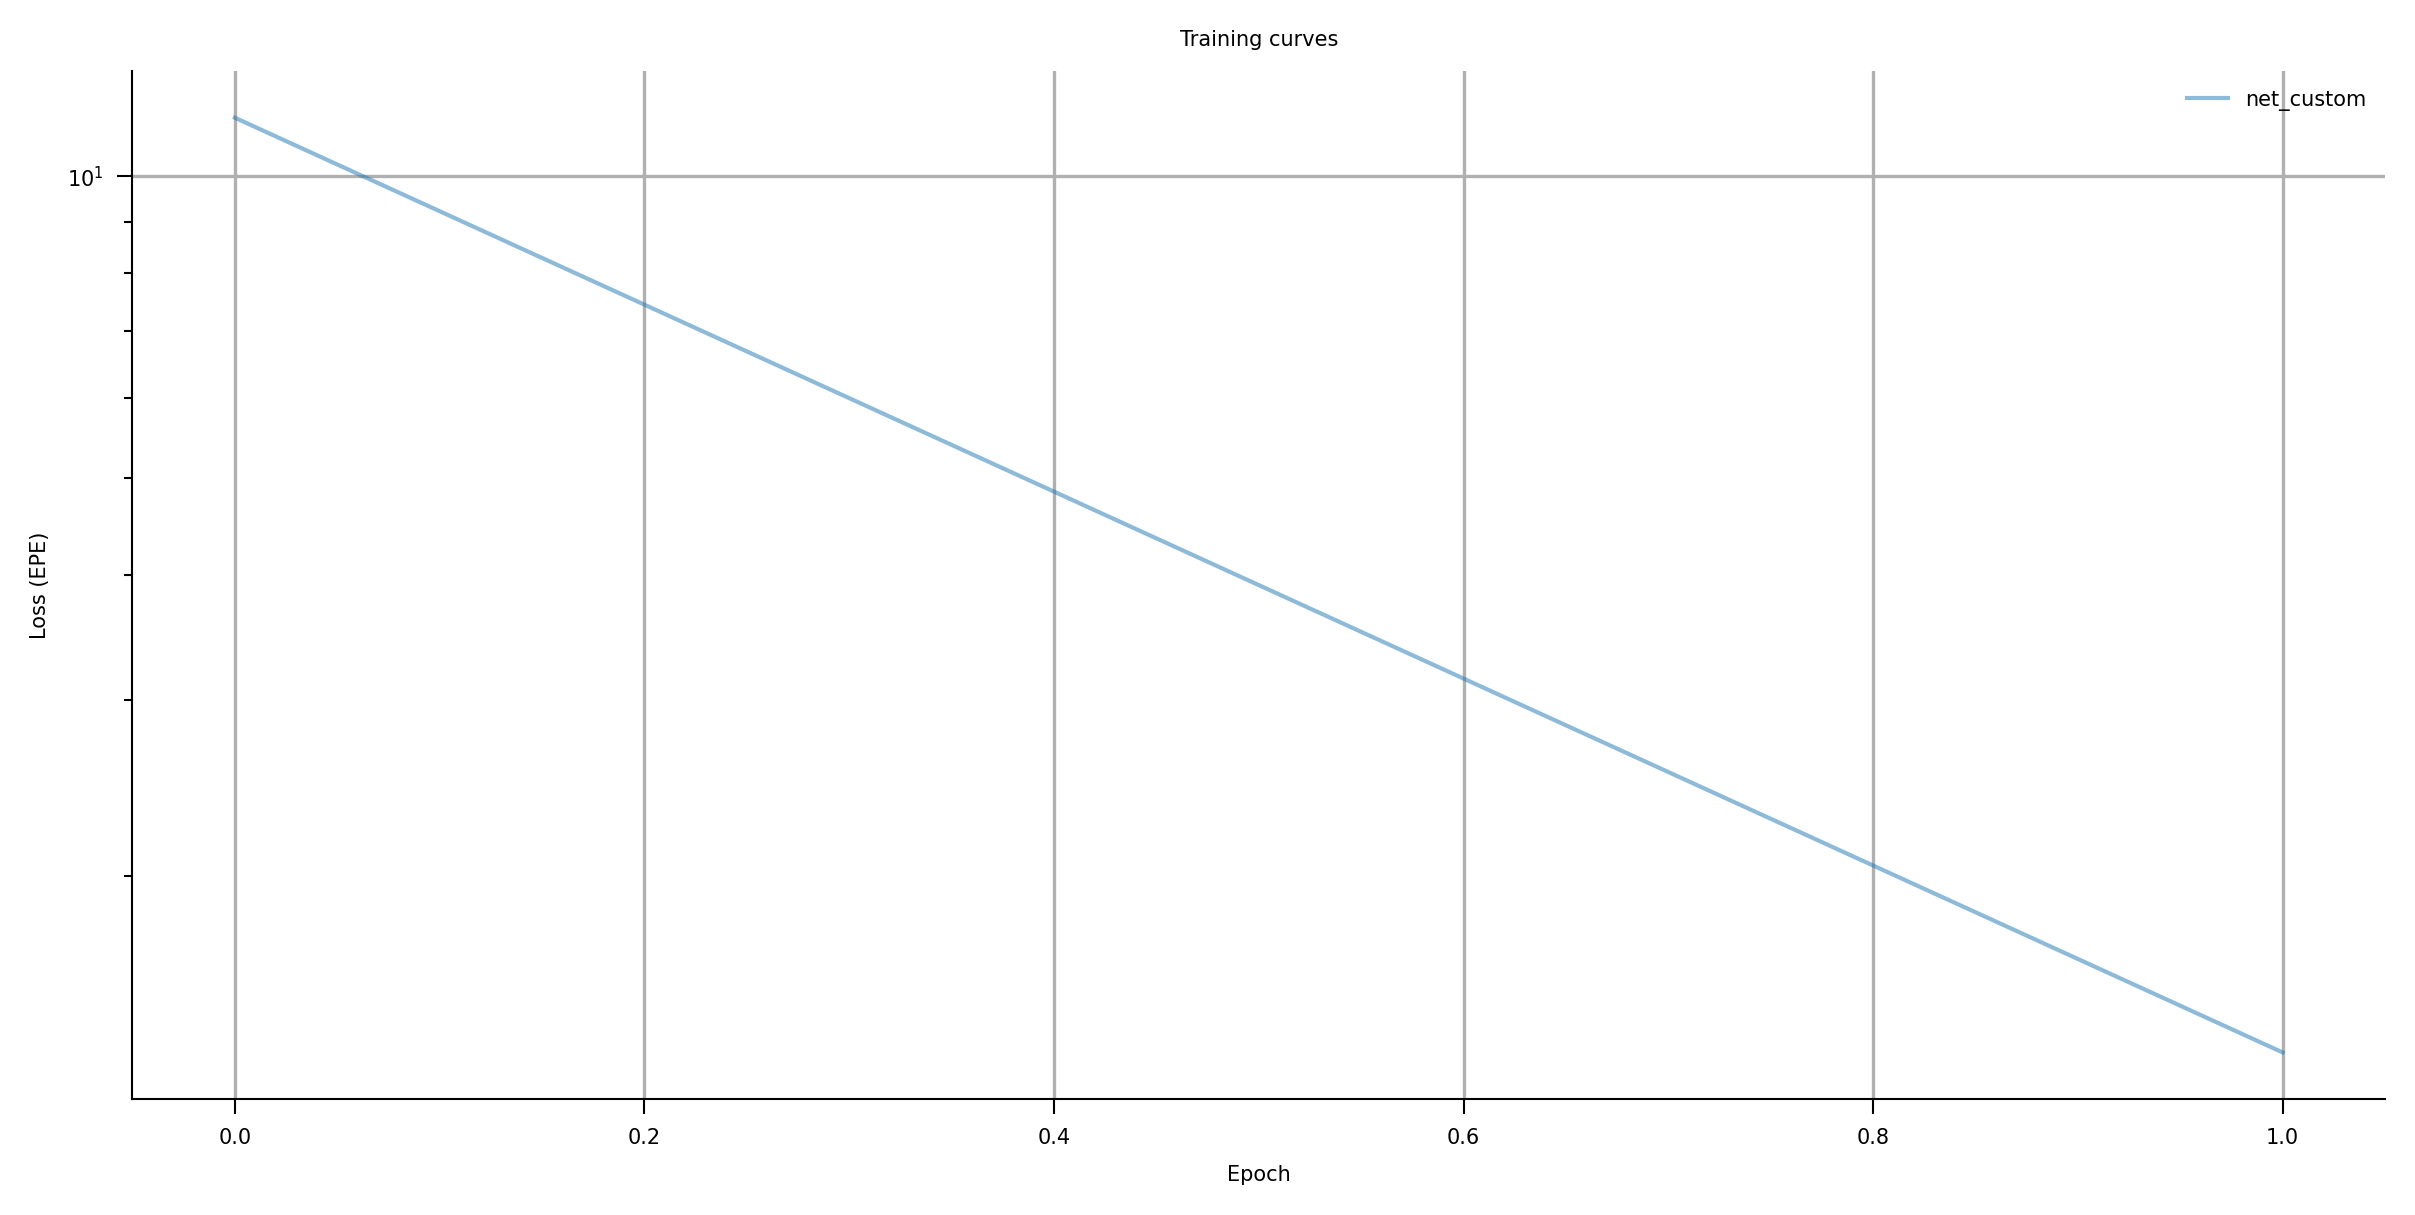

In [13]:


plt.figure(figsize=(8,4))
plt.plot(errors_custom,  label="net_custom",   alpha=0.5)
plt.yscale("log"); plt.xlabel("Epoch"); plt.ylabel("Loss (EPE)")
plt.title("Training curves"); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


In [14]:
ckpt_dir = Path("best_models")          # folder with the .pth files

net_custom.load_state_dict(
    torch.load(ckpt_dir / "net_custom_weights_v3_k9_1500.pth", map_location="cpu")
)
decoder_custom.load_state_dict(
    torch.load(ckpt_dir / "decoder_custom_weights_v3_k9_1500.pth", map_location="cpu")
)

<All keys matched successfully>

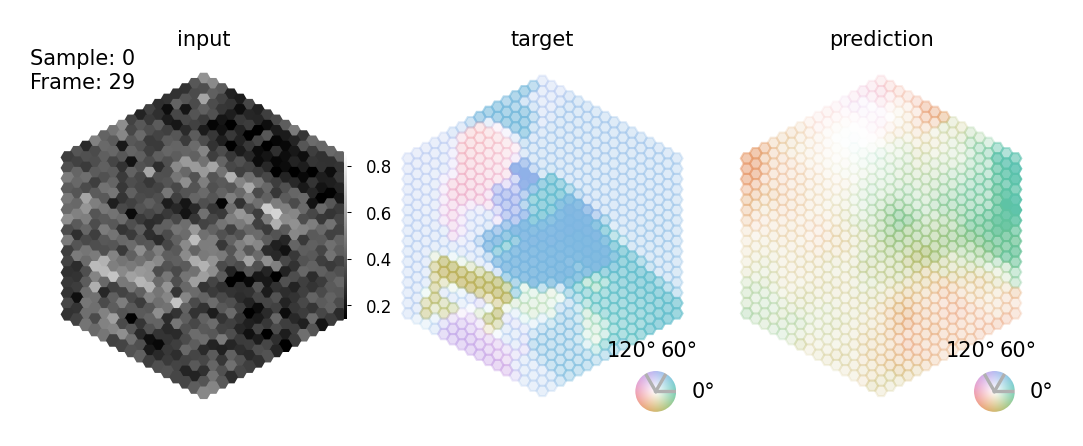

In [15]:
batch = next(iter(train_loader))
seq = 13
lum = batch["lum"]   # Remove batch dimension
flow= batch["flow"][seq] # Remove batch dimension

net_custom.stimulus.zero()
net_custom.stimulus.add_input(lum)
activity_custom = net_custom(net_custom.stimulus(), dt=1/50, state=initial_state_custom)
y_pred_custom = decoder_custom(activity_custom)
print(y_pred_custom.shape,)
#net_default.stimulus.zero()
#net_default.stimulus.add_input(lum)
#activity_default = net_default(net_default.stimulus(), dt=1/50, state=initial_state_default)

#y_pred_default = decoder_default(activity_default)

lum = batch["lum"][seq]   # Remove batch dimension
flow = batch["flow"][seq] # Remove batch dimension
pred = y_pred_custom[seq,:,:,:]
animation = SintelSample(lum[None], flow[None], prediction=pred[None].detach().cpu())
animation.animate_in_notebook()


In [16]:
print(y_pred_custom.shape,flow.shape)
((y_pred_custom[:,1:,:,:] - flow[1:,:,:]) ** 2).sqrt().mean()

torch.Size([16, 30, 2, 721]) torch.Size([30, 2, 721])


tensor(5.0577, device='cuda:0', grad_fn=<MeanBackward0>)

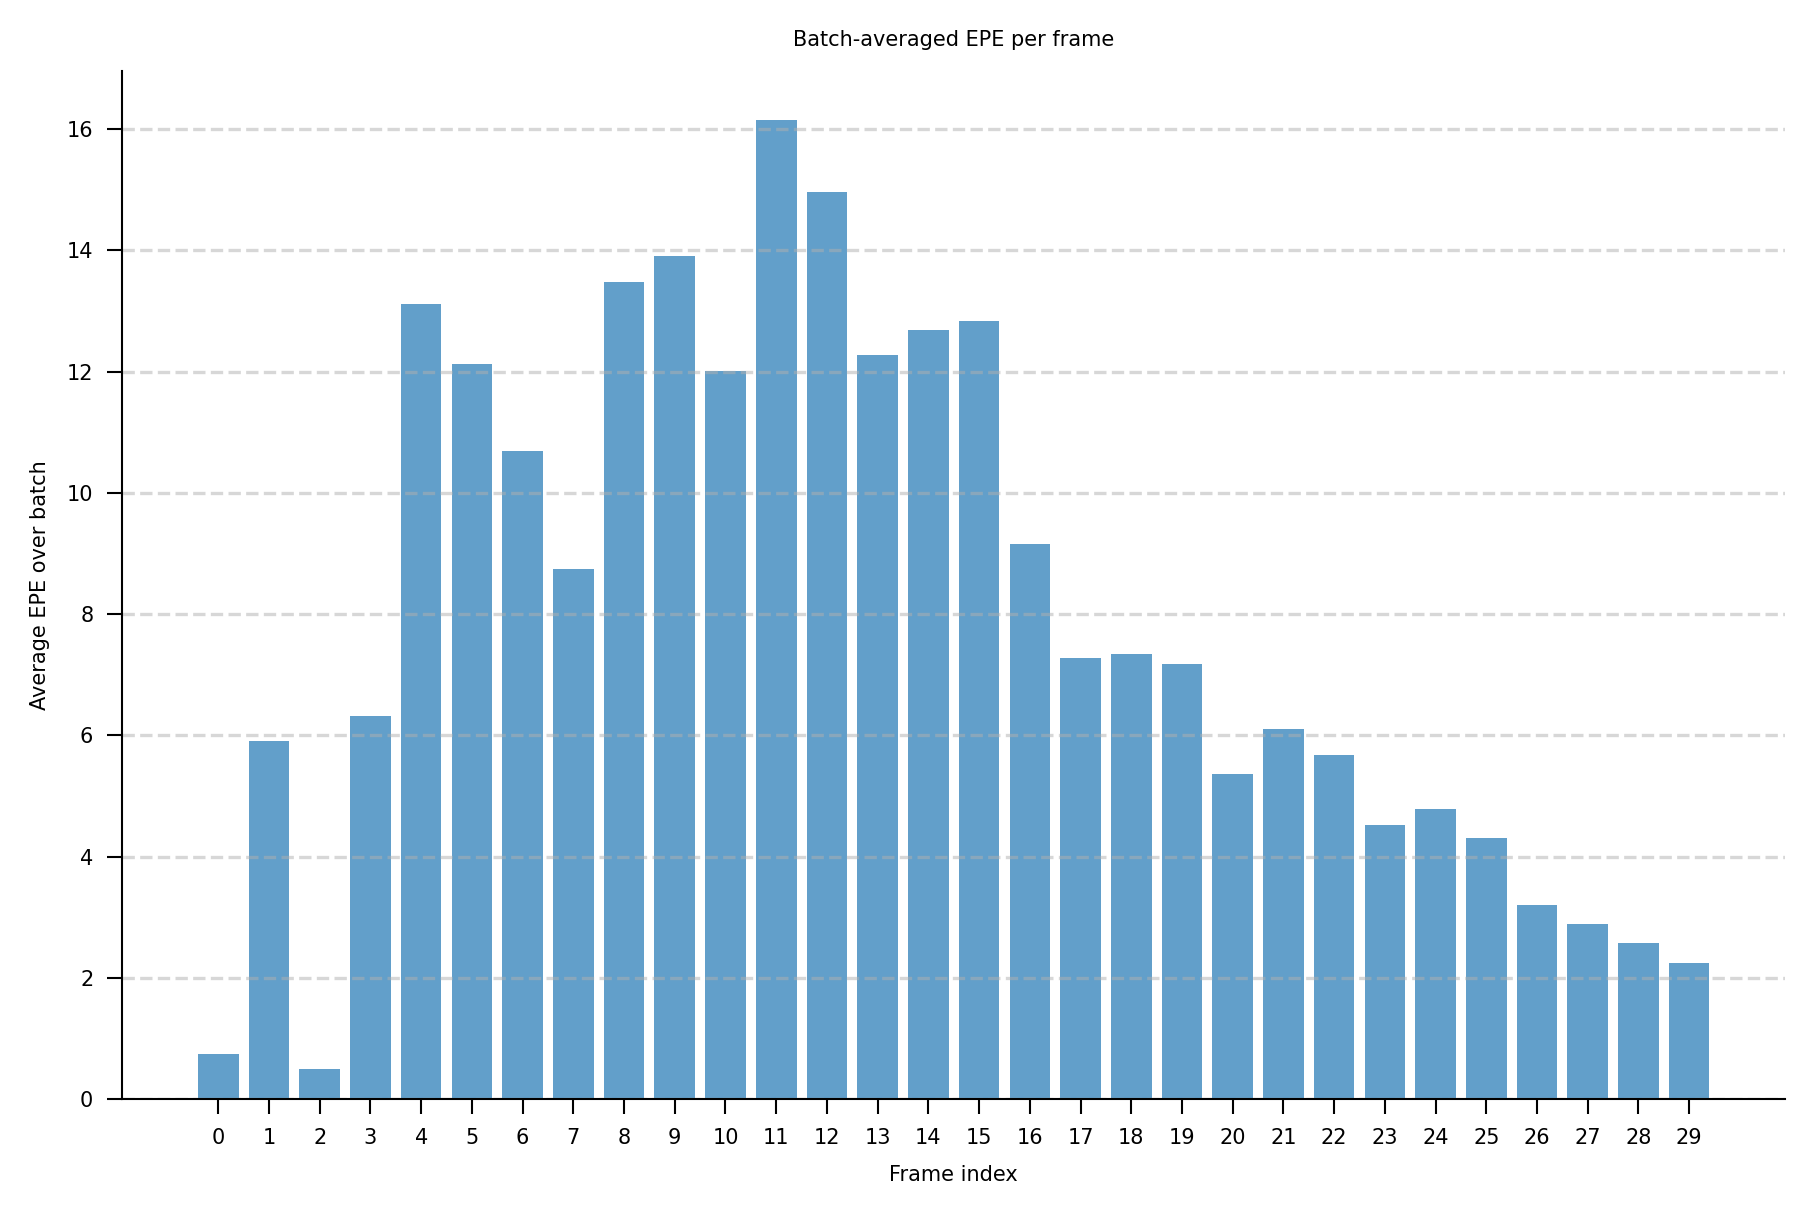

In [17]:
import matplotlib.pyplot as plt
import numpy as np

y_pred_all = y_pred_custom.detach().cpu().numpy()  # (B, T, 2, 721)
gt_all     = batch["flow"].detach().cpu().numpy()  # (B, T, 2, 721)

B, T, _, _ = y_pred_all.shape

# Pre‐allocate
errors_per_frame = np.zeros(T)

for t in range(T):
    # diff_t: shape (B, 2, 721)
    diff_t = y_pred_all[:, t, :, :] - gt_all[:, t, :, :]
    # mag_t: shape (B, 721), since axis=1 reduces the "2"-dim into per‐pixel norm
    mag_t = np.linalg.norm(diff_t, axis=1)   # <-- axis=1, not axis=0
    # Now average over all pixels (dim=1) and all batch entries
    errors_per_frame[t] = mag_t.mean()

plt.figure(figsize=(6, 4))
plt.bar(np.arange(T), errors_per_frame, alpha=0.7)
plt.xlabel("Frame index")
plt.ylabel("Average EPE over batch")
plt.title("Batch‐averaged EPE per frame")
plt.xticks(np.arange(T))
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [18]:
torch.save(net_custom.state_dict(), "net_custom_weights.pth")

torch.save(decoder_custom.state_dict(), "decoder_custom_weights.pth")

In [19]:
def run():

    epochs = 2000                                    # ← any number you like
    def grad_stats(model: torch.nn.Module) -> float:
        g = [p.grad.abs().mean() for p in model.parameters() if p.grad is not None]
        return torch.stack(g).mean().item() if g else 0.



    # ── set-up (same as before) ────────────────────────────────────────────
    errors_custom, errors_default = [], []

    initial_state_custom  = net_custom.steady_state(t_pre, dt, batch_size)
    initial_state_default = net_default.steady_state(t_pre, dt, batch_size)

    decoder_custom  = DecoderGAVP(net_custom.connectome, shape=[8, 2], kernel_size=5)
    decoder_default = DecoderGAVP(net_default.connectome, shape=[8, 2], kernel_size=5)

    opt_custom  = Adam((*net_custom.parameters(),  *decoder_custom.parameters()),  lr=lr)
    opt_default = Adam((*net_default.parameters(), *decoder_default.parameters()), lr=lr)

    # ── training loop with nice tqdm output ───────────────────────────────
    for e in range(epochs):
        pb = tqdm(train_loader, desc=f"Epoch {e+1}/{epochs}", leave=False,miniters=50)  # one bar per epoch
        epoch_loss_custom  = 0.0
        epoch_loss_default = 0.0

        for lum, flow in ((b["lum"], b["flow"]) for b in pb):
            # zero & feed input
            opt_custom.zero_grad();  net_custom.stimulus.zero();  net_custom.stimulus.add_input(lum)
            opt_default.zero_grad(); net_default.stimulus.zero(); net_default.stimulus.add_input(lum)

            # forward
            act_cust  = net_custom(net_custom.stimulus(),  dt=1/50, state=initial_state_custom)
            act_def   = net_default(net_default.stimulus(), dt=1/50, state=initial_state_default)
            y_cust    = decoder_custom(act_cust)
            y_def     = decoder_default(act_def)

            # loss & back-prop
            loss_cust = loss_fn(y_cust, flow);   loss_def = loss_fn(y_def, flow)
            loss_cust.backward();                loss_def.backward()
            opt_custom.step();                   opt_default.step()

            epoch_loss_custom  += loss_cust.item()
            epoch_loss_default += loss_def.item()
            pb.set_postfix({
                "batch_cust": f"{loss_cust.item():.4f}",
                "batch_def":  f"{loss_def.item():.4f}"
            })
            if e % 1 == 0:  # debug every epoch
                print(f"ep{e:02d}  "
                    f"mean|grad| net={grad_stats(net_custom):.2e}  "
                    f"dec={grad_stats(decoder_custom):.2e}  "
                    f"loss={loss_cust.item():.4f}")

        # epoch means
        epoch_loss_custom  /= len(train_loader)
        epoch_loss_default /= len(train_loader)
        errors_custom.append(epoch_loss_custom)
        errors_default.append(epoch_loss_default)

        pb.write(f"Epoch {e+1:>3}: custom={epoch_loss_custom:.4f} | default={epoch_loss_default:.4f}")
    # ── plot after training (unchanged) ───────────────────────────────────
    plt.figure(figsize=(8,4))
    plt.plot(errors_default, label="net (default)", alpha=0.5)
    plt.plot(errors_custom,  label="net_custom",   alpha=0.5)
    plt.yscale("log"); plt.xlabel("Epoch"); plt.ylabel("Loss (EPE)")
    plt.title("Training curves"); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


    torch.save(net_custom.state_dict(), "net_custom_weights.pth")
    torch.save(decoder_custom.state_dict(), "decoder_custom_weights.pth")
    torch.save(net_default.state_dict(), "net_default_weights.pth")
    torch.save(decoder_default.state_dict(), "decoder_default_weights.pth")